# Notebook overview

This notebook demonstrates three abstraction levels provided by sudspy, moving from raw PC-SUDS internals to standard ObsPy objects.

**1.	Block level**
    
Direct access to the linear SUDS block stream via iter_suds_blocks.
Useful for inspecting file structure, debugging ordering, and understanding how SRC/PC-SUDS files are laid out.

**2.	Parser & collection level**
    
Structured decoding of individual block types (e.g. STATIONCOMP, DESCRIPTRACE, INSTRUMENT, FEATURE), plus higher-level collection helpers that assemble station metadata, instruments, comments, and picks.

**3.	Obspy level**
    
High-level readers (read_suds_stream, read_suds_inv, read_suds_picks) that convert SUDS files directly into standard ObsPy Stream, Inventory, and Event/Pick objects for analysis and response removal.

The examples below progress through these layers in order, showing how low-level SUDS structures map cleanly onto familiar ObsPy workflows.

## 1. Block level

In [1]:
import sudspy
from sudspy.blocks import iter_suds_blocks
from sudspy.utils import print_suds_block_structure
from sudspy.utils import test_collect_comments


print_suds_block_structure(
    "../data/multi_stations/2_stations.sud",
    max_blocks=8
)


SUDS block listing for: ../data/multi_stations/2_stations.sud

  5  STATIONCOMP     offset=0
 31  INSTRUMENT      offset=120
  7  DESCRIPTRACE    offset=246
 20  COMMENT         offset=60354
  5  STATIONCOMP     offset=60833
 31  INSTRUMENT      offset=60953
  7  DESCRIPTRACE    offset=61079
 20  COMMENT         offset=121187

[truncated]


## 2. Parser and collection level

In [2]:
from sudspy.parsers import parse_descriptrace_struct
from sudspy.constants import SUDS_STRUCT_TYPES
from sudspy.collections import collect_stations, collect_instruments, collect_comments

In [3]:
path = "../data/multi_stations/2_stations.sud"

for i, block in enumerate(iter_suds_blocks(path)):
    name = SUDS_STRUCT_TYPES.get(block.struct_type, "UNKNOWN")
    print(f"{i:03d}  type={block.struct_type:2d}  {name:12s}  offset={block.offset}")
    if i > 10:
        break

000  type= 5  STATIONCOMP   offset=0
001  type=31  INSTRUMENT    offset=120
002  type= 7  DESCRIPTRACE  offset=246
003  type=20  COMMENT       offset=60354
004  type= 5  STATIONCOMP   offset=60833
005  type=31  INSTRUMENT    offset=60953
006  type= 7  DESCRIPTRACE  offset=61079
007  type=20  COMMENT       offset=121187
008  type= 5  STATIONCOMP   offset=121631
009  type=31  INSTRUMENT    offset=121751
010  type= 7  DESCRIPTRACE  offset=121877
011  type=20  COMMENT       offset=181985


In [4]:
for block in iter_suds_blocks(path):
    if block.struct_type == 7:  # DESCRIPTRACE
        desc = parse_descriptrace_struct(block)
        break
desc

{'struct_type': 7,
 'statident': {'network': 'VW', 'station': 'TRPU', 'component': 'E'},
 'longident': {'network': 'VW', 'station': 'TRPU', 'component': 'CHE'},
 'struct_body': {'begintime': 1765368840.0,
  'localtime': 0,
  'datatype': 'l',
  'descriptor': '_',
  'digi_by': -32767,
  'processed': -32767,
  'length': 15000,
  'rate': 250.0,
  'mindata': -2960.0,
  'maxdata': 2322.0,
  'avenoise': 0.2150000035762787,
  'numclip': -32767,
  'time_correct': 0.0,
  'rate_correct': 0.0},
 'offset': 246,
 'raw_len': 96}

In [5]:
stats = collect_stations("../data/multi_stations/2_stations.sud")
stats.keys()

dict_keys(['VW.TRPU.CHE', 'VW.LOCU.CHE', 'VW.LOCU.CHN', 'VW.TRPU.CHZ', 'VW.LOCU.CHZ', 'VW.TRPU.CHN'])

In [6]:
instruments = collect_instruments("../data/multi_stations/2_stations.sud")
instruments.keys()

dict_keys(['VW.TRPU.CHE', 'VW.LOCU.CHE', 'VW.LOCU.CHN', 'VW.TRPU.CHZ', 'VW.LOCU.CHZ', 'VW.TRPU.CHN'])

In [7]:
comments = collect_comments("../data/multi_stations/2_stations.sud")
comments.keys()

dict_keys(['VW.TRPU.CHE', 'VW.LOCU.CHE', 'VW.LOCU.CHN', 'VW.TRPU.CHZ', 'VW.LOCU.CHZ', 'VW.TRPU.CHN'])

# 3. Obspy  level

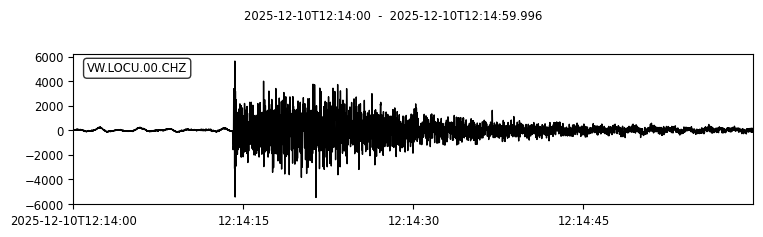

In [8]:
st = sudspy.read_suds_stream("../data/single_chan/locu_seismosphere.sud", default_location="00")
st[0].plot();

In [9]:
inv = sudspy.read_suds_inv("../data/single_chan/locu_seismosphere.sud", default_location="00")

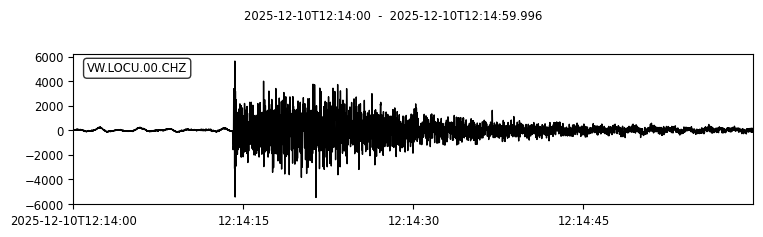

In [10]:
st[0].plot();

In [11]:
st.remove_response(
    inventory=inv)

1 Trace(s) in Stream:
VW.LOCU.00.CHZ | 2025-12-10T12:14:00.000000Z - 2025-12-10T12:14:59.996000Z | 250.0 Hz, 15000 samples

In [12]:
picks = sudspy.read_suds_picks(
    "../data/multi_chan_picks/locu.dmx",
    location_code=""
)

for p in picks:
    print(p)

Pick
	 resource_id: ResourceIdentifier(id="smi:local/27257270-6c22-43e6-b4e4-30afd6228094")
	        time: UTCDateTime(2025, 12, 10, 12, 14, 19, 885000)
	 waveform_id: WaveformStreamID(network_code='VW', station_code='LOCU', channel_code='CHN', location_code='')
	  phase_hint: 'S'
Pick
	 resource_id: ResourceIdentifier(id="smi:local/079de39e-1b60-46ee-8b3f-315ee9e6c0e5")
	        time: UTCDateTime(2025, 12, 10, 12, 14, 14, 130000)
	 waveform_id: WaveformStreamID(network_code='VW', station_code='LOCU', channel_code='CHZ', location_code='')
	  phase_hint: 'P'


## Utils

In [13]:
from obspy import Stream
from sudspy.utils import fast_merge_safe

In [14]:
ls ../data/multi_files/


combined.sud  overlaps/     sequence/


In [15]:
!cat ../data/multi_files/*.dmx > ../data/multi_files/combined.sud

cat: ../data/multi_files/*.dmx: No such file or directory


In [16]:
st = sudspy.read_suds_stream("../data/multi_files/sequence/combined.suds", default_location="00")


In [17]:
%%time
# --- build merged 3C stream ---
# discover channels present in the stream
chans = sorted({tr.stats.channel.strip() for tr in st})

merged = Stream()

for ch in chans:
    traces = [tr for tr in st if tr.stats.channel.strip() == ch]
    if not traces:
        continue
    merged += fast_merge_safe(
                traces,
                gap_fill="nan",
                overlap="trim",
            )

#merged.write("../data/fast_merge_safe.mseed", format="MSEED")

CPU times: user 3.07 ms, sys: 3.54 ms, total: 6.6 ms
Wall time: 4.13 ms


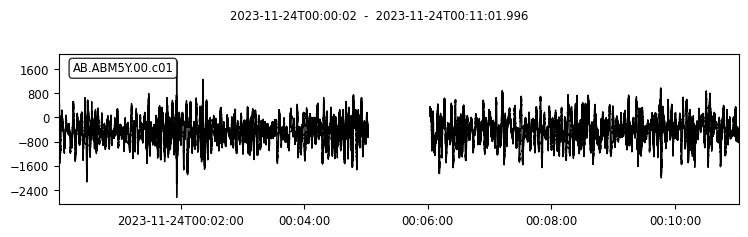

In [18]:
merged[0].plot();

## More tests

The test here consist of a 3 overlapping files: a 3 channel velocity sensor (uploaded from SD card), and overlapping 1 channel (z) telemetered file, as well as partially overlapping accelerometer.

In [19]:
st = sudspy.read_suds_stream("../data/multi_files/overlaps/combined.dmx", default_location="00")


In [20]:
print(st)

7 Trace(s) in Stream:
AB.ABM5Y.00.c03 | 2023-11-24T20:57:02.000000Z - 2023-11-24T20:58:01.996000Z | 250.0 Hz, 15000 samples
AB.ABM5Y.00.c01 | 2023-11-24T20:57:02.000000Z - 2023-11-24T20:58:01.996000Z | 250.0 Hz, 15000 samples
AB.ABM5Y.00.c02 | 2023-11-24T20:57:02.000000Z - 2023-11-24T20:58:01.996000Z | 250.0 Hz, 15000 samples
AB.ABM5Y.00.c03 | 2023-11-24T20:57:02.000000Z - 2023-11-24T20:58:01.996000Z | 250.0 Hz, 15000 samples
AB.ABM5Y.00.c04 | 2023-11-24T20:57:48.000000Z - 2023-11-24T20:58:48.996000Z | 250.0 Hz, 15250 samples
AB.ABM5Y.00.c05 | 2023-11-24T20:57:48.000000Z - 2023-11-24T20:58:48.996000Z | 250.0 Hz, 15250 samples
AB.ABM5Y.00.c06 | 2023-11-24T20:57:48.000000Z - 2023-11-24T20:58:48.996000Z | 250.0 Hz, 15250 samples


In [21]:
%%time
# --- build merged 3C stream ---
# discover channels present in the stream
chans = sorted({tr.stats.channel.strip() for tr in st})

merged = Stream()

for ch in chans:
    traces = [tr for tr in st if tr.stats.channel.strip() == ch]
    if not traces:
        continue
    merged += fast_merge_safe(
                traces,
                gap_fill="nan",
                overlap="trim",
            )

CPU times: user 2.06 ms, sys: 693 μs, total: 2.75 ms
Wall time: 2.18 ms


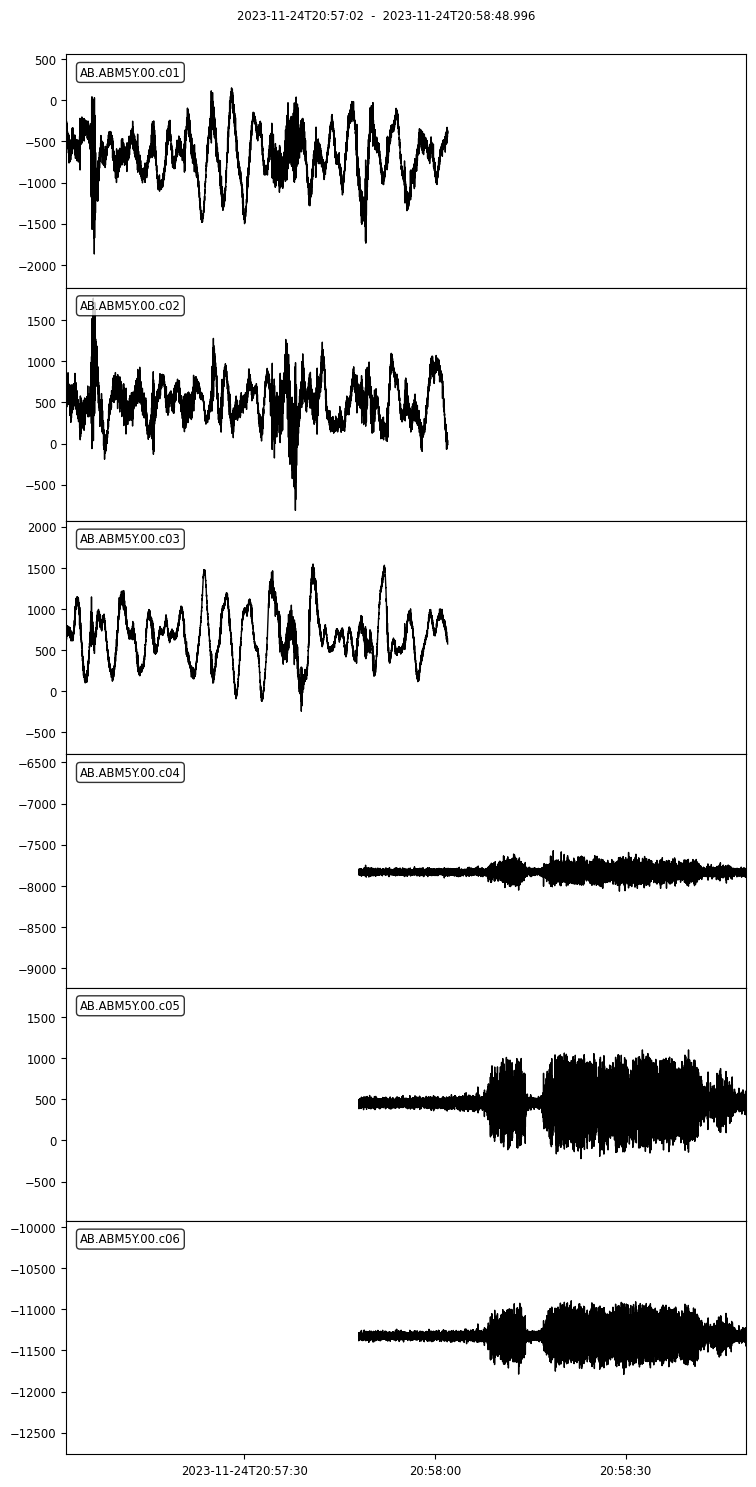

In [22]:
merged.plot();

In [23]:
print(merged)

6 Trace(s) in Stream:
AB.ABM5Y.00.c01 | 2023-11-24T20:57:02.000000Z - 2023-11-24T20:58:01.996000Z | 250.0 Hz, 15000 samples
AB.ABM5Y.00.c02 | 2023-11-24T20:57:02.000000Z - 2023-11-24T20:58:01.996000Z | 250.0 Hz, 15000 samples
AB.ABM5Y.00.c03 | 2023-11-24T20:57:02.000000Z - 2023-11-24T20:58:01.996000Z | 250.0 Hz, 15000 samples
AB.ABM5Y.00.c04 | 2023-11-24T20:57:48.000000Z - 2023-11-24T20:58:48.996000Z | 250.0 Hz, 15250 samples
AB.ABM5Y.00.c05 | 2023-11-24T20:57:48.000000Z - 2023-11-24T20:58:48.996000Z | 250.0 Hz, 15250 samples
AB.ABM5Y.00.c06 | 2023-11-24T20:57:48.000000Z - 2023-11-24T20:58:48.996000Z | 250.0 Hz, 15250 samples
